In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data3 = pd.read_csv("exoplanet_data.csv", comment = '#')
print(data3.shape)

(583, 92)


In [12]:
small_data3 = data3[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]

small_data3 = small_data3.dropna()
print(small_data3.shape)
print(small_data3.head())
print(small_data3.tail())
print(small_data3.columns)

#The smaller dataset has 70 rows and 6 columns 
#first 5 rows show exoplanets name, host sars, discovery methods, spectral types, eq temperatures, and masses. 
#The last 5 rows show additional exoplanets in the dataset and confirm the structure is the same
#pl_name(planet name), hostname, discoverymethod, st_spectype, pl_eqt, pl_bmassj 

(70, 6)
     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

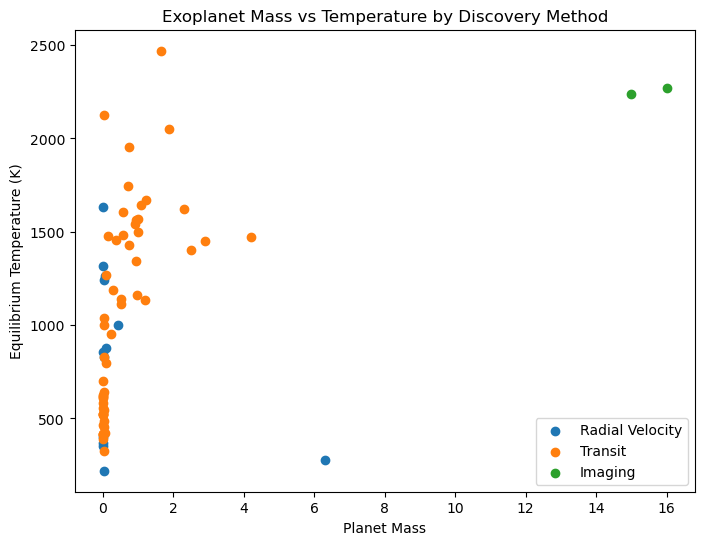

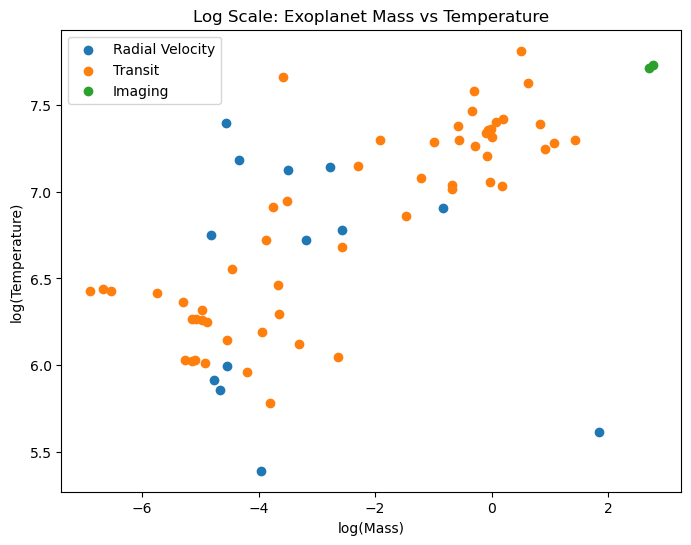

eps Ind A b
581
275.0
6.31
K5 V


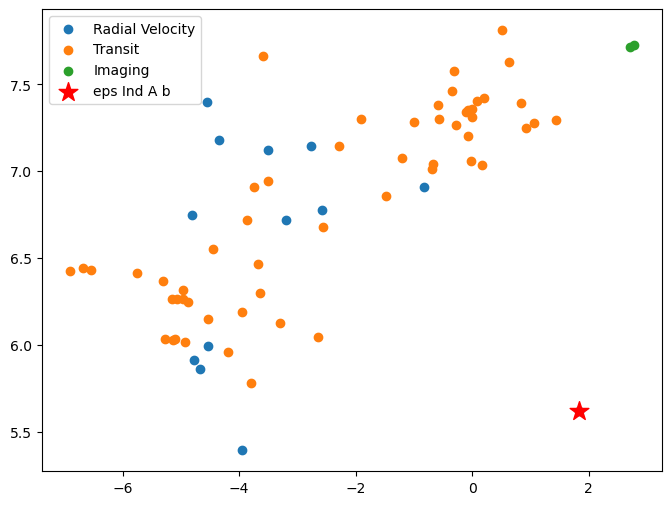

In [16]:
small_data3["discoverymethod"].value_counts()
plt.figure(figsize=(8,6))
for method in small_data3["discoverymethod"].unique():
    subset = small_data3[small_data3["discoverymethod"] == method]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label=method)
plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature (K)")
plt.title("Exoplanet Mass vs Temperature by Discovery Method")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

for method in small_data3["discoverymethod"].unique():
    subset = small_data3[small_data3["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)
plt.xlabel("log(Mass)")
plt.ylabel("log(Temperature)")
plt.title("Log Scale: Exoplanet Mass vs Temperature")
plt.legend()
plt.show()

#Imaging planets tend to be more massive and planets that are bigger are easier to detect 

filtered = small_data3[small_data3["pl_bmassj"] > 5]
coldest = filtered.loc[filtered["pl_eqt"].idxmin()]
coldest
print(coldest["pl_name"])
print(coldest.name)  # index
print(coldest["pl_eqt"])
print(coldest["pl_bmassj"])
print(coldest["st_spectype"])

plt.figure(figsize=(8,6))
for method in small_data3["discoverymethod"].unique():
    subset = small_data3[small_data3["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)

# highlight coldest planet
plt.scatter(
    np.log(coldest["pl_bmassj"]),
    np.log(coldest["pl_eqt"]),
    color="red",
    s=200,
    marker="*",
    label=coldest["pl_name"]
)
plt.legend()
plt.show()

#A temperate super-Jupiter imaged with JWST in the mid-infrared 
#The paper is focused on the discovery of a directly imaged giant exoplanet orbiting the nearby star Epsilon Indi A using JWST. The star is like Sun in age and it was considered a planer prior. 
#Yes the selected exoplanet matches the paper in that it is massive, cold giant planet that was likely directly imaged. 
#The planet is a very massive giant planet that has a low temp compared to other planets. 
#no they dont match the paper describes a giant planet with a temperature of approx 275 k while selected planet has a different equilibrium temperature and a different estimated mass (greater than 5 Jupiter masses).